# K_Means_Clustering

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
print('Libraries imported')

Libraries imported


In [13]:
data={
    'customer_id':[1,2,3,4,5,6,7,8,9,10],
    'Annual_income':[15,16,17,18,30,35,40,45,60,65],
    'Spending_score':[39,81,6,77,40,76,6,94,3,72]
}

df=pd.DataFrame(data)
df.info

<bound method DataFrame.info of    customer_id  Annual_income  Spending_score
0            1             15              39
1            2             16              81
2            3             17               6
3            4             18              77
4            5             30              40
5            6             35              76
6            7             40               6
7            8             45              94
8            9             60               3
9           10             65              72>

In [14]:
df.shape

(10, 3)

In [15]:
df.head()

,customer_id,Annual_income,Spending_score
0,1,15,39
1,2,16,81
2,3,17,6
3,4,18,77
4,5,30,40


In [16]:
df.isnull().sum()

customer_id       0
Annual_income     0
Spending_score    0
dtype: int64

In [17]:
X=df[['Annual_income','Spending_score']]
inertia=[]
for k in range(1,8):
    model=KMeans(n_clusters=k)
    model.fit(X)
    inertia.append(model.inertia_)



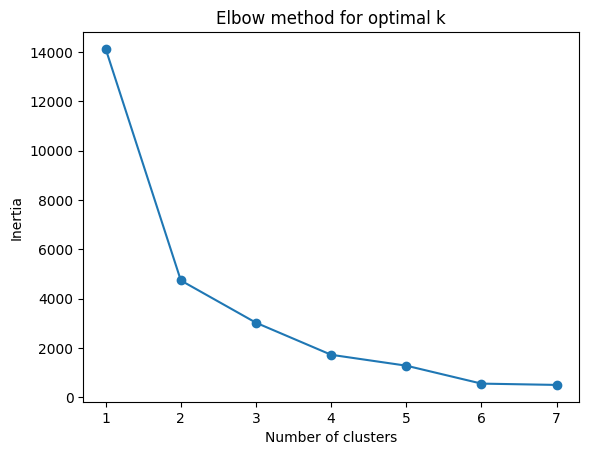

In [18]:
plt.plot(range(1,8),inertia,marker='o')
plt.title('Elbow method for optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

plt.show()

In [19]:
kmeans=KMeans(n_clusters=3, random_state=42)
df['Cluster']=kmeans.fit_predict(X)
print(df)

   customer_id  Annual_income  Spending_score  Cluster
0            1             15              39        2
1            2             16              81        0
2            3             17               6        2
3            4             18              77        0
4            5             30              40        2
5            6             35              76        0
6            7             40               6        1
7            8             45              94        0
8            9             60               3        1
9           10             65              72        0


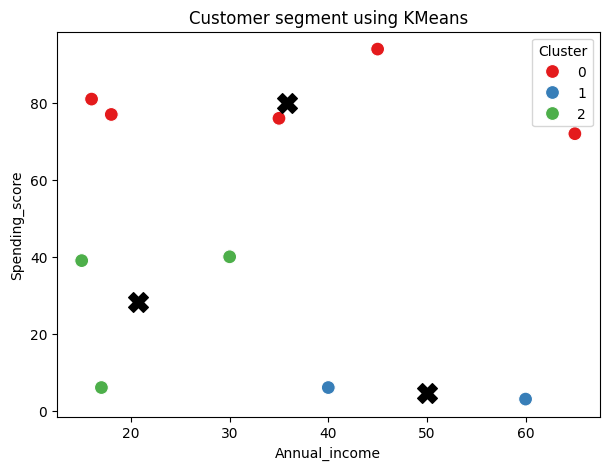

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Annual_income',y='Spending_score',hue='Cluster',data=df, palette='Set1', s=100)
centers=kmeans.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],c='black',s=200,marker='X',label='Centroids')
plt.title('Customer segment using KMeans')
plt.show()